# Checking the data

In [1]:
%run 'load-data.ipynb'

Building DAG of jobs...
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process_data/validated
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process_data/validated
['root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process_data/validated/rds_final_2012_90000000_magdown_rs.root', 'root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process_data/validated/rds_final_2012_90000000_magup_rs.root']
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated
Loading files from %s root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated
['root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/final/ap_post_process/validated/rds_final_2012_23903000_magdown

In [2]:
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (15,6)

In [3]:
data.shape, mc.shape

((73852, 57), (228577, 66))

In [4]:
set(mc.columns) - set(data.columns)

{'Xc_BKGCAT',
 'Xc_Selection',
 'Xc_signal_Ypis_displaced_fromBs_fromTau',
 'category',
 'fromY_from_B_vertex',
 'key',
 'signal',
 'simplified',
 'simplified_key'}

## Checking the Y, Xc and B mass

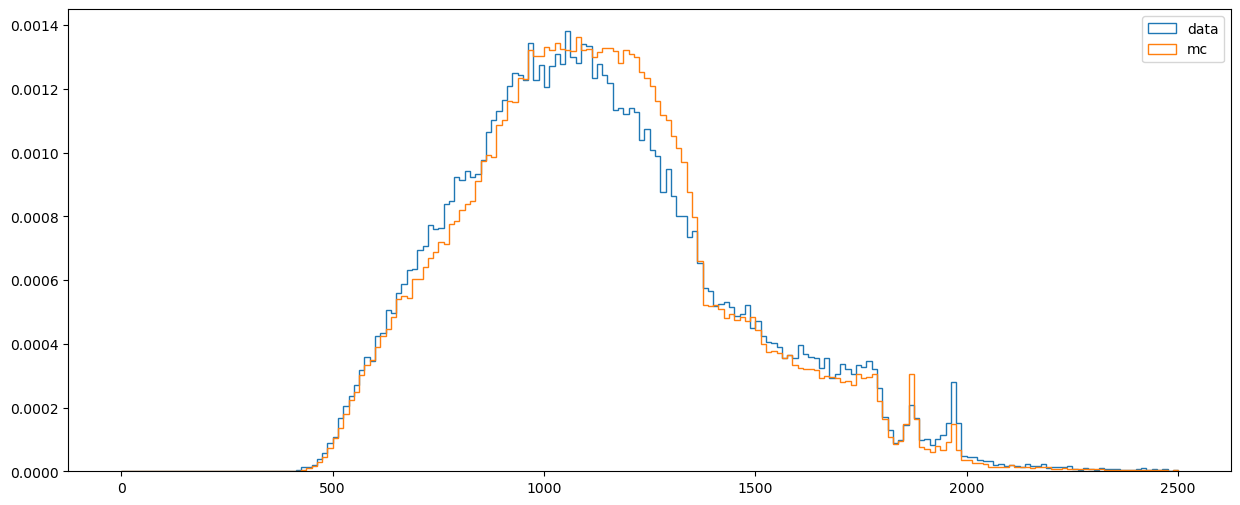

In [5]:
myrange=[0, 2500]
plt.hist(data.Y_M, bins=200,  histtype='step', density=True, label="data", range=myrange)

plt.hist(mc.Y_M, bins=200, histtype='step', density=True, label="mc", range=myrange)
plt.legend();

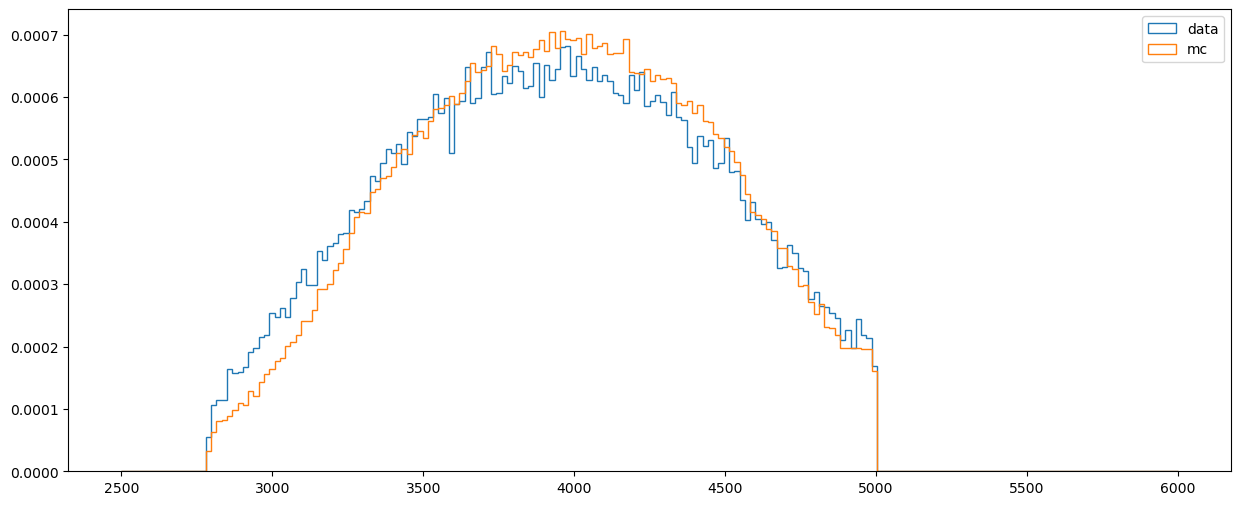

In [6]:
myrange=[2500, 6000]
plt.hist(data.B_M, bins=200,  histtype='step', density=True, label="data", range=myrange)
plt.hist(mc.B_M, bins=200, histtype='step', density=True, label="mc", range=myrange)
plt.legend();

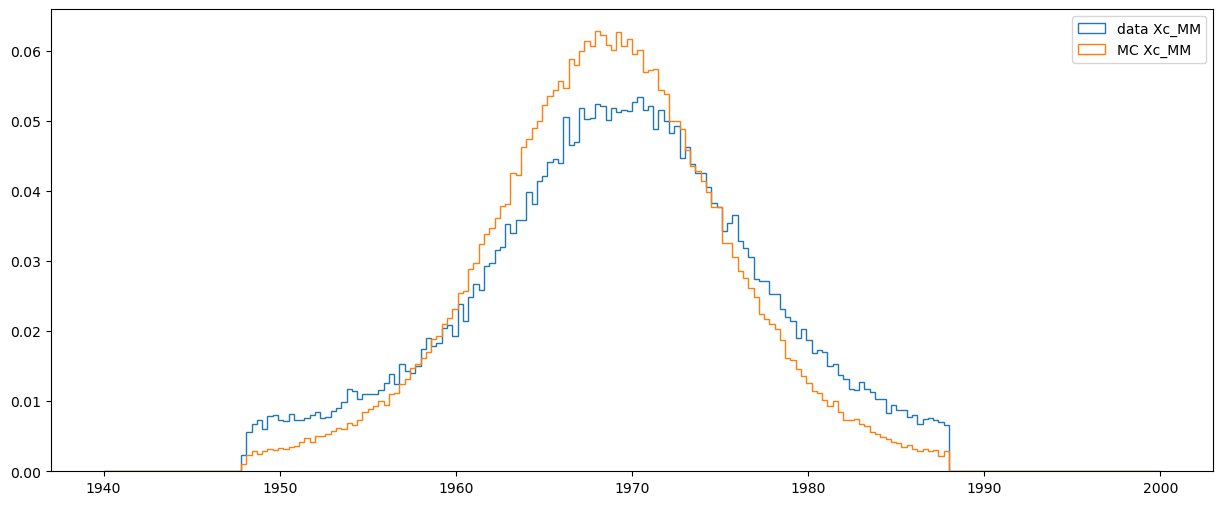

In [7]:
myrange=[1940, 2000]
plt.hist(data.Xc_MM, bins=200, 
         label= 'data Xc_MM', histtype='step', density=True, range=myrange);
plt.hist(mc.Xc_MM, bins=200, 
         label= 'MC Xc_MM', histtype='step', density=True, range=myrange);
plt.legend();

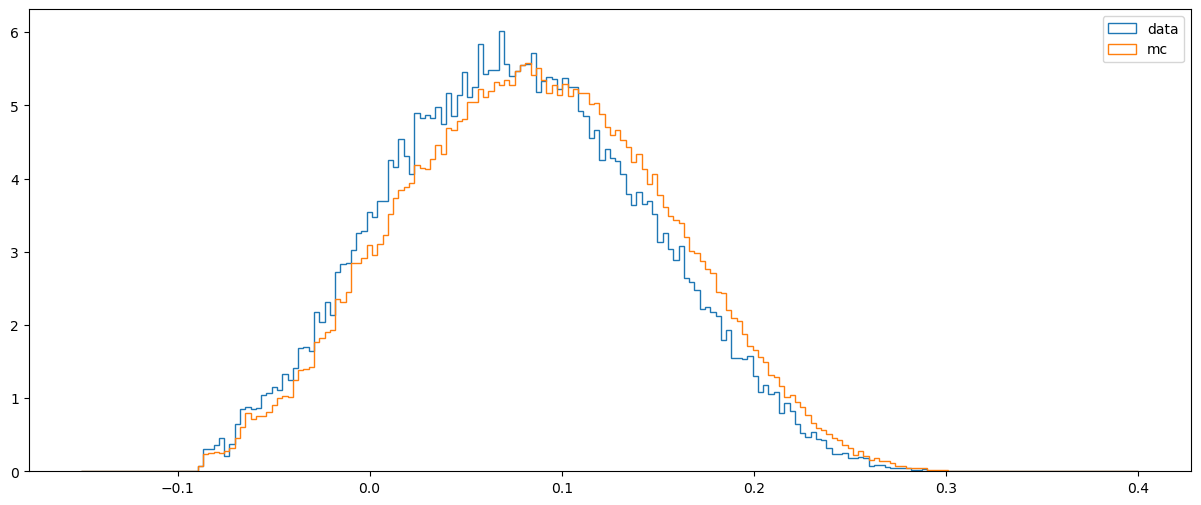

In [8]:
myrange = [ -0.15, 0.40]
plt.hist(data.BDT_Ds, bins=200, 
         label= 'data', histtype='step', density=True, range=myrange);
plt.hist(mc.BDT_Ds, bins=200, 
         label= 'mc', histtype='step', density=True, range=myrange);
plt.legend();

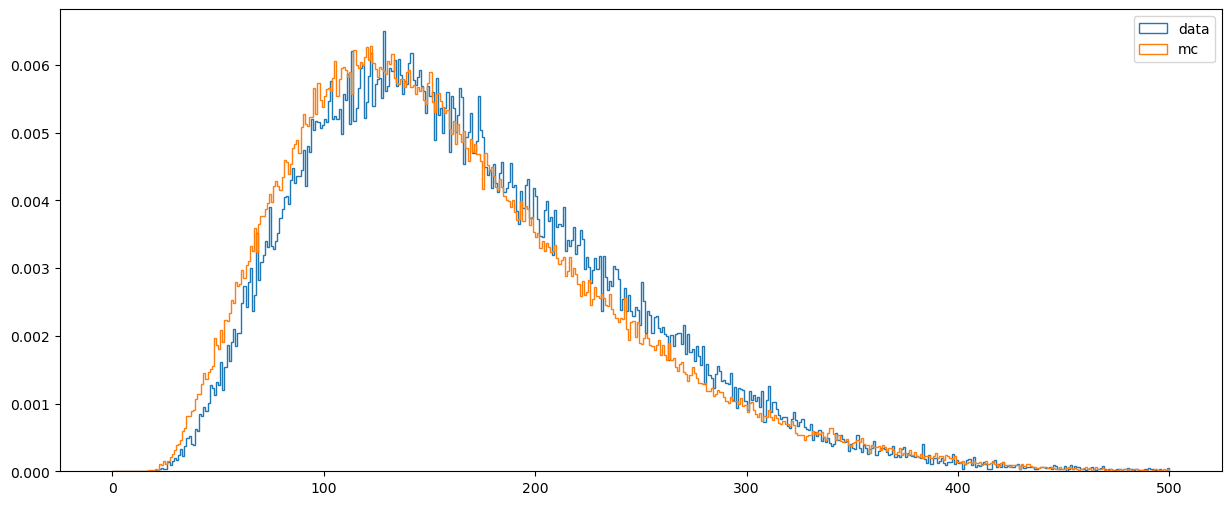

In [9]:
myrange = [0, 500]
nbins=500
plt.hist(data.nTracks, bins=nbins, 
         label= 'data', histtype='step', density=True, range=myrange);
res = plt.hist(mc.nTracks, bins=nbins, 
         label= 'mc', histtype='step', density=True, range=myrange);
plt.legend();

In [10]:
def mygroupby(d, groupbycols):
    """ Utility to group by a column and show relative statistics """
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

In [11]:
print(f"Total candidates: {len(data)}")
c = mygroupby(data, "eventNumber")
print(f"Distinct events {len(c)}")
cmult = c.query("count > 1")
print(f"Nb events with multiple candidates {len(cmult)}")
cmult

Total candidates: 73852
Distinct events 72014
Nb events with multiple candidates 1586


,eventNumber,count,Percentage,cumulative %
0,1817680888,6,0.008124,0.008124
1,678358989,6,0.008124,0.016249
2,2396885319,6,0.008124,0.024373
3,1462863022,5,0.006770,0.031143
4,429205036,5,0.006770,0.037914
...,...,...,...,...
1581,950367063,2,0.002708,4.625467
1582,2336951501,2,0.002708,4.628175
1583,2324533945,2,0.002708,4.630883
1584,233334039,2,0.002708,4.633592


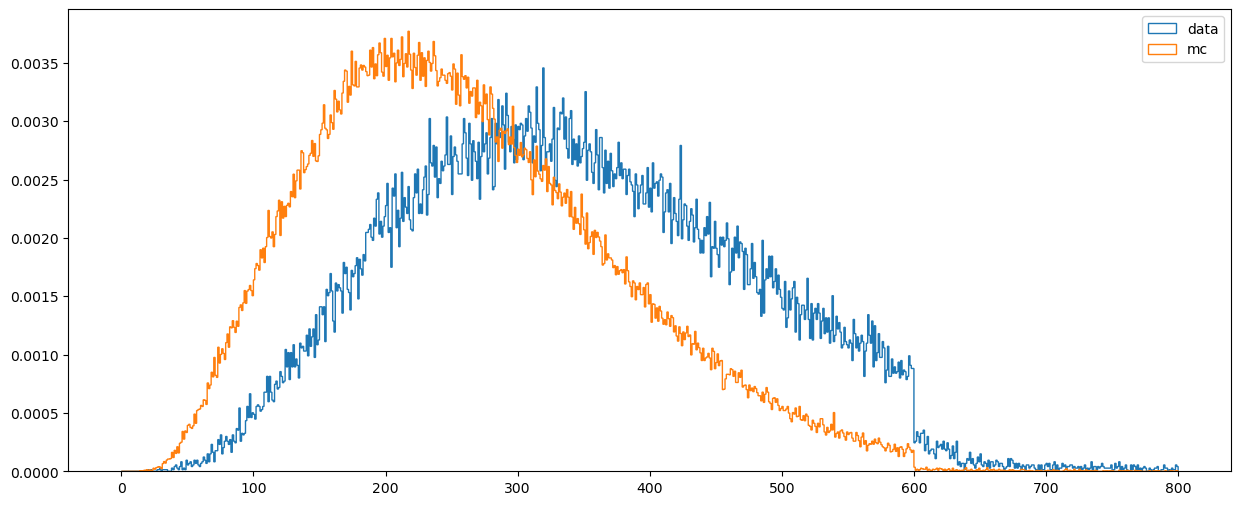

In [12]:
myrange = [0, 800]
nbins=800
res = plt.hist(data.nSPDHits, bins=nbins, 
         label= 'data', histtype='step', density=True, range=myrange);
res = plt.hist(mc.nSPDHits, bins=nbins, 
         label= 'mc', histtype='step', density=True, range=myrange);
plt.legend();

# Checking Isolation BDT response

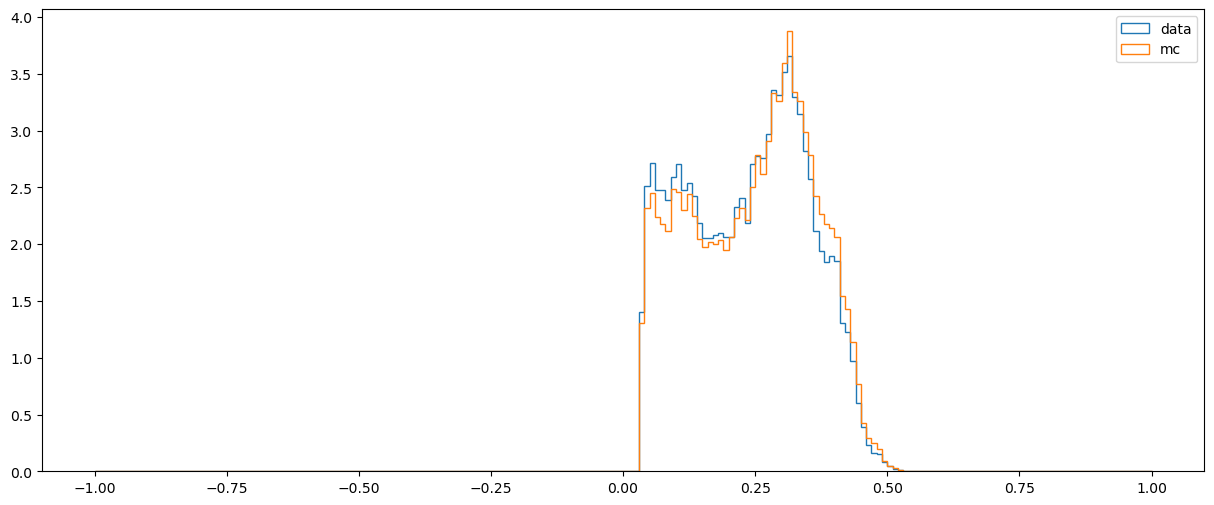

In [13]:
isorange=[-1, 1]
plt.hist(data.BDT_Iso, bins=200, 
         label= 'data', histtype='step', density=True, range=isorange);
plt.hist(mc.BDT_Iso, bins=200, 
         label= 'mc', histtype='step', density=True, range=isorange);
plt.legend();

## Applying a tigher cut on BDT_Iso

In [14]:
isocutval = 0
dataiso = data.query(f"BDT_Iso > {isocutval}")
mciso = mc.query(f"BDT_Iso > {isocutval}")

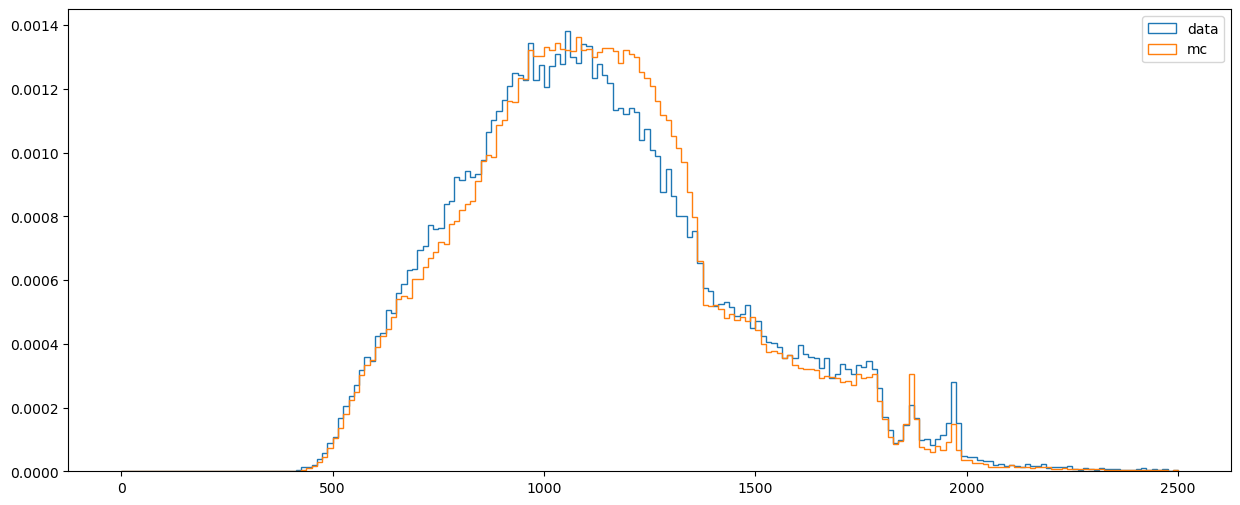

In [15]:
myrange=[0, 2500]
plt.hist(dataiso.Y_M, bins=200, 
         label= 'data', histtype='step', density=True, range=myrange);
plt.hist(mciso.Y_M, bins=200, 
         label= 'mc', histtype='step', density=True, range=myrange);

plt.legend();

## Checking the B_Y_SEP

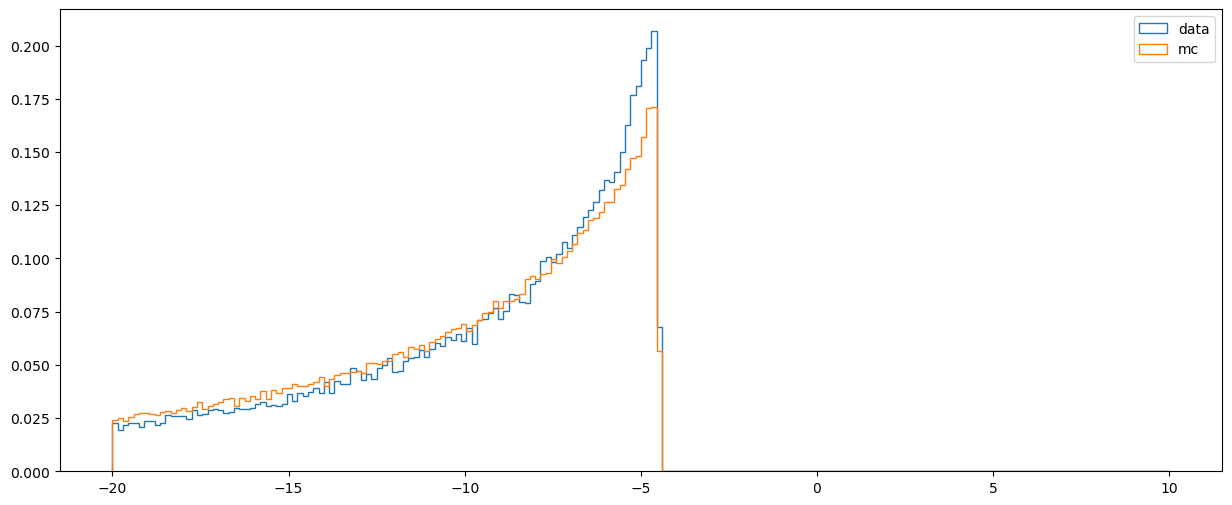

In [16]:
myrange=[-20, 10]
plt.hist(dataiso.B_Y_SEP, bins=200, 
         label= 'data', histtype='step', density=True, range=myrange);
plt.hist(mciso.B_Y_SEP, bins=200, 
         label= 'mc', histtype='step', density=True, range=myrange);
plt.legend();

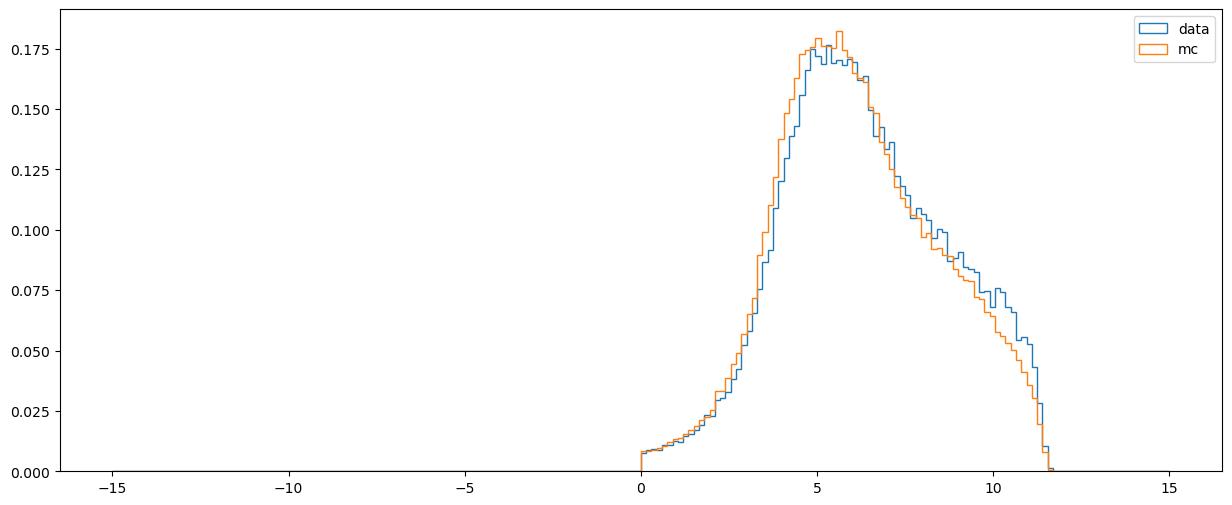

In [17]:
myrange=[-15, 15]
plt.hist(dataiso.q2_2, bins=200, 
         label= 'data', histtype='step', density=True, range=myrange);
plt.hist(mciso.q2_2, bins=200, 
         label= 'mc', histtype='step', density=True, range=myrange);
plt.legend();

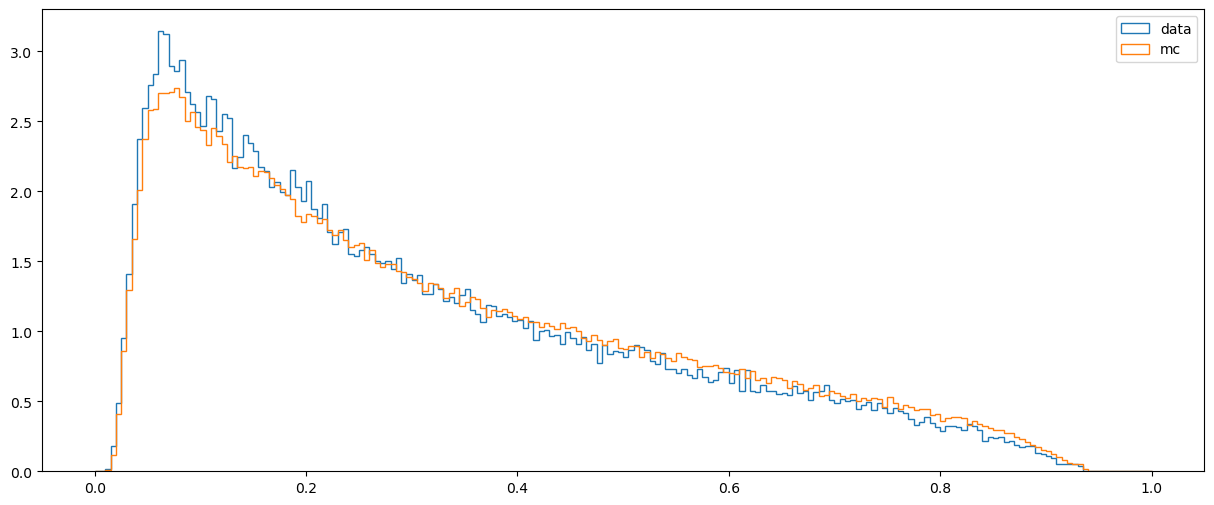

In [18]:
myrange=[0, 1]
plt.hist(dataiso.bdt_dc, bins=200, 
         label= 'data', histtype='step', density=True, range=myrange);
plt.hist(mciso.bdt_dc, bins=200, 
         label= 'mc', histtype='step', density=True, range=myrange);

plt.legend();